# Exploración de Datos y Modelo de Clasificación — Marketing Bancario UniBank

**Problema de Clasificación: Predicción de Adquisición de Producto**
Grupo 4 — Modelos Estadísticos

## 0. Instalación e importación de librerías

In [1]:
paquetes <- c("tidyverse", "ggplot2", "corrplot", "moments", "gridExtra",
              "scales", "knitr", "reshape2", "GGally", "car", "MASS",
              "caret", "pROC", "e1071")

nuevos <- paquetes[!(paquetes %in% installed.packages()[, "Package"])]
if (length(nuevos) > 0) install.packages(nuevos, quiet = TRUE)

library(tidyverse)
library(ggplot2)
library(corrplot)
library(moments)
library(gridExtra)
library(scales)
library(knitr)
library(reshape2)
library(GGally)
library(car)
library(MASS)
library(caret)
library(pROC)
library(e1071)

options(scipen = 999, digits = 3)
cat(" Librerías cargadas correctamente\n")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
corrplot 0.95 loaded


Adjuntando el paquete: 'gridExtra'


The following object is masked from 'package:dplyr':

    combine



Adjuntando el paquete: 'scales'


The following object is masked from 'package:purrr':

    discard


The following object is masked from 'package:readr':

    col_factor



Adjuntando el paquete: 'reshape2'


The following object is masked from 'package:tidyr':

    smiths


Warning message:
"package 'car' was built under R version 4.6.1"
Carga

 Librerías cargadas correctamente


## 1. Exploración inicial y estructura de datos

In [2]:
train <- read.csv("../../data/raw/clasificacion/Train bank.csv", stringsAsFactors = TRUE)
test  <- read.csv("../../data/raw/clasificacion/Test bank.csv",  stringsAsFactors = TRUE)

test_ids <- test$X
train$X <- NULL
test$X  <- NULL

train$Subscription <- as.factor(train$Subscription)

cat("Dimensiones train:", nrow(train), "x", ncol(train), "\n")
cat("Dimensiones test :", nrow(test), "x", ncol(test), "\n")
str(train)

Dimensiones train: 31648 x 17 
Dimensiones test : 13563 x 16 
'data.frame':	31648 obs. of  17 variables:
 $ Age                  : int  58 44 33 47 35 28 42 58 43 53 ...
 $ Job                  : Factor w/ 12 levels "admin.","blue-collar",..: 5 10 3 2 5 5 3 6 10 10 ...
 $ Marital.Status       : Factor w/ 3 levels "divorced","married",..: 2 3 2 2 2 3 1 2 3 2 ...
 $ Education            : Factor w/ 4 levels "primary","secondary",..: 3 2 2 4 3 3 3 1 2 2 ...
 $ Credit               : Factor w/ 2 levels "no","yes": 1 1 1 1 1 1 2 1 1 1 ...
 $ Balance..euros.      : int  2143 29 2 1506 231 447 2 121 593 6 ...
 $ Housing.Loan         : Factor w/ 2 levels "no","yes": 2 2 2 2 2 2 2 2 2 2 ...
 $ Personal.Loan        : Factor w/ 2 levels "no","yes": 1 1 2 1 1 2 1 1 1 1 ...
 $ Contact              : Factor w/ 3 levels "cellular","telephone",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ Last.Contact.Day     : int  5 5 5 5 5 5 5 5 5 5 ...
 $ Last.Contact.Month   : Factor w/ 12 levels "apr","aug","dec",..: 9 9 9 9 9

## 2. Análisis Univariado

### 2.1 Variable objetivo: Subscription

Distribución de Subscription:

    0     1 
27951  3697 

Proporción (%):

   0    1 
88.3 11.7 


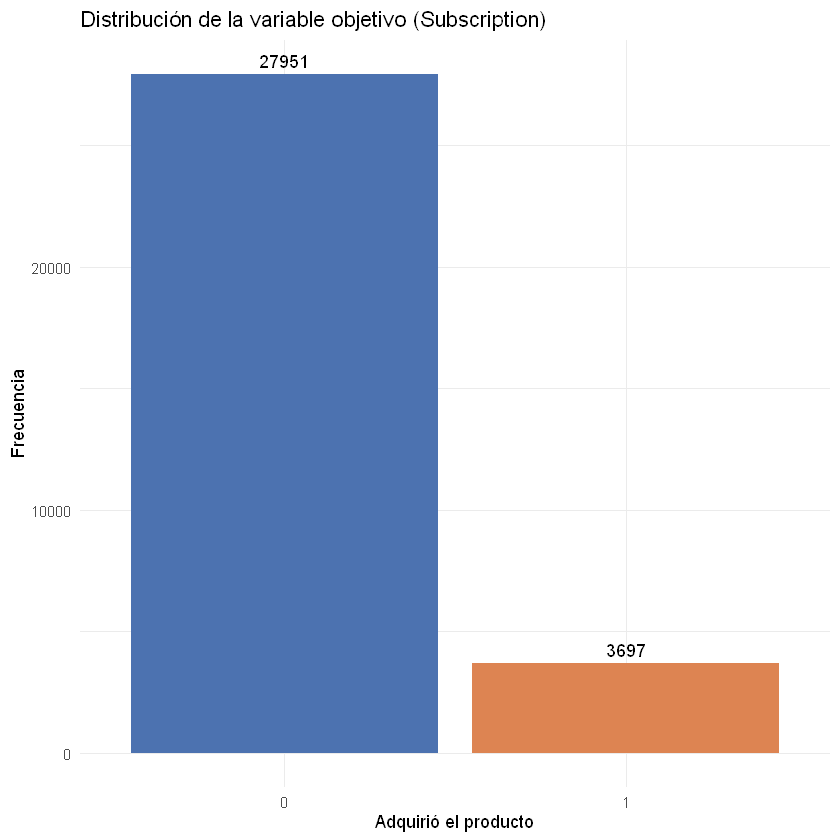

In [3]:
tabla_sub <- table(train$Subscription)
prop_sub <- prop.table(tabla_sub) * 100

cat("Distribución de Subscription:\n")
print(tabla_sub)
cat("\nProporción (%):\n")
print(round(prop_sub, 2))

ggplot(train, aes(x = Subscription, fill = Subscription)) +
  geom_bar() +
  geom_text(stat = "count", aes(label = after_stat(count)), vjust = -0.5) +
  scale_fill_manual(values = c("0" = "#4C72B0", "1" = "#DD8452")) +
  labs(title = "Distribución de la variable objetivo (Subscription)",
       x = "Adquirió el producto", y = "Frecuencia") +
  theme_minimal() +
  theme(legend.position = "none")
ggsave("../../outputs/figures/clasificacion_balance_clases.png", width = 6, height = 4, dpi = 150)

### 2.2 Variables numéricas: estadísticas descriptivas

In [4]:
num_cols <- c("Age", "Balance..euros.", "Last.Contact.Day", "Last.Contact.Duration",
              "Campaign", "Pdays", "Previous")

estadisticas_num <- train %>%
  summarise(across(all_of(num_cols),
    list(media = ~mean(.), mediana = ~median(.), sd = ~sd(.),
         min = ~min(.), q25 = ~quantile(., 0.25), q75 = ~quantile(., 0.75),
         max = ~max(.)))) %>%
  pivot_longer(everything(), names_to = c("variable", ".value"), names_pattern = "(.*)_(.*)")

print(estadisticas_num)
write.csv2(estadisticas_num, "../../outputs/tables/clasificacion_estadisticas_numericas.csv", row.names = FALSE)

# A tibble: 7 × 8
  variable                 media mediana      sd   min   q25   q75    max
  <chr>                    <dbl>   <dbl>   <dbl> <int> <dbl> <dbl>  <int>
1 Age                     40.9        39   10.6     18    33    48     95
2 Balance..euros.       1377.        452 3089.   -8019    72  1438 102127
3 Last.Contact.Day        15.8        16    8.33     1     8    21     31
4 Last.Contact.Duration  257.        179  255.       0   103   317   3422
5 Campaign                 2.76        2    3.12     1     1     3     63
6 Pdays                   39.9        -1   99.8     -1    -1    -1    871
7 Previous                 0.586       0    2.48     0     0     0    275


### 2.3 Distribución de variables numéricas (histogramas)

agg_record_2b2427ca345 
                     2

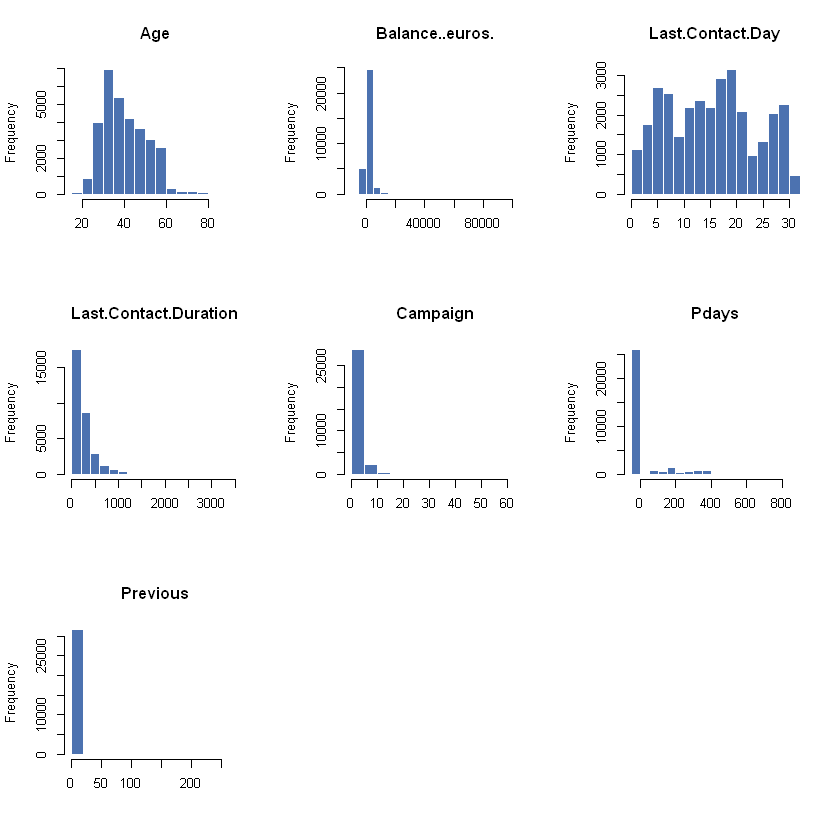

In [5]:
png("../../outputs/figures/clasificacion_histogramas_numericas.png", width = 1100, height = 900, res = 120)
par(mfrow = c(3, 3))
for (col in num_cols) {
  hist(train[[col]], main = col, xlab = "", col = "#4C72B0", border = "white")
}
dev.off()

par(mfrow = c(3, 3))
for (col in num_cols) {
  hist(train[[col]], main = col, xlab = "", col = "#4C72B0", border = "white")
}

### 2.4 Variables categóricas: frecuencias

In [6]:
cat_cols <- c("Job", "Marital.Status", "Education", "Credit", "Housing.Loan",
              "Personal.Loan", "Contact", "Last.Contact.Month", "Poutcome")

for (col in cat_cols) {
  cat("\n===", col, "===\n")
  print(table(train[[col]]))
}


=== Job ===

       admin.   blue-collar  entrepreneur     housemaid    management 
         3592          6763          1067           868          6594 
      retired self-employed      services       student    technician 
         1604          1125          2951           671          5278 
   unemployed       unknown 
          932           203 

=== Marital.Status ===

divorced  married   single 
    3619    19027     9002 

=== Education ===

  primary secondary  tertiary   unknown 
     4838     16118      9386      1306 

=== Credit ===

   no   yes 
31065   583 

=== Housing.Loan ===

   no   yes 
14175 17473 

=== Personal.Loan ===

   no   yes 
26559  5089 

=== Contact ===

 cellular telephone   unknown 
    20497      2021      9130 

=== Last.Contact.Month ===

 apr  aug  dec  feb  jan  jul  jun  mar  may  nov  oct  sep 
2040 4431  155 1863  959 4838 3747  330 9582 2787  519  397 

=== Poutcome ===

failure   other success unknown 
   3435    1251    1061   25901 


agg_record_2b24df521b 
                    2

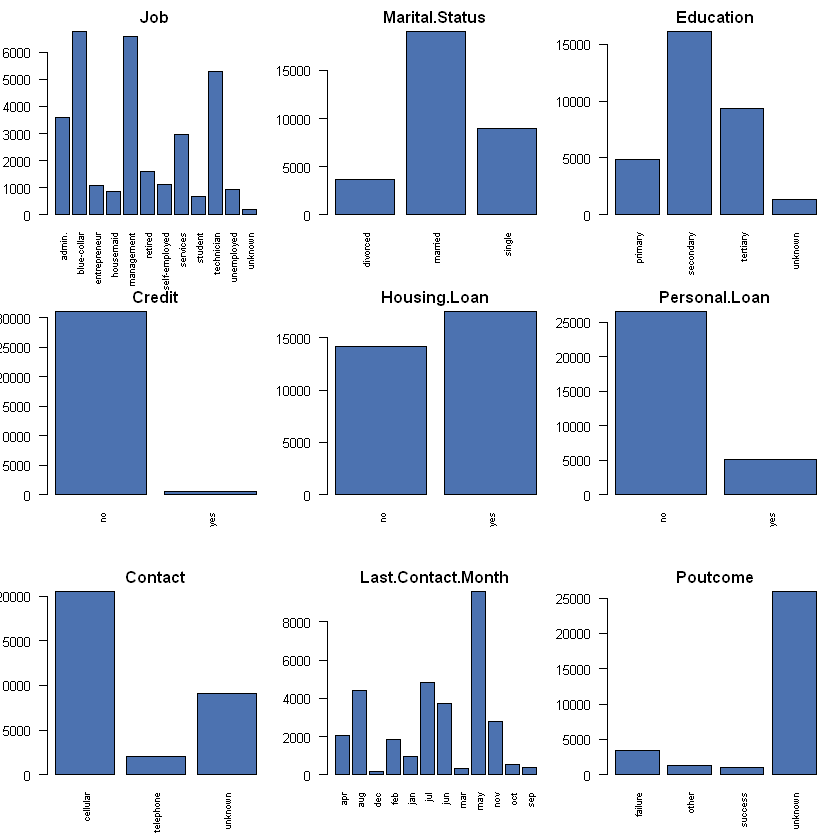

In [7]:
png("../../outputs/figures/clasificacion_categoricas_frecuencia.png", width = 1100, height = 1000, res = 110)
par(mfrow = c(3, 3), mar = c(4, 3, 2, 1))
for (col in cat_cols) {
  barplot(table(train[[col]]), main = col, las = 2, cex.names = 0.7, col = "#4C72B0")
}
dev.off()

par(mfrow = c(3, 3), mar = c(4, 3, 2, 1))
for (col in cat_cols) {
  barplot(table(train[[col]]), main = col, las = 2, cex.names = 0.7, col = "#4C72B0")
}

## 3. Análisis Bivariado: relación con la variable objetivo

### 3.1 Numéricas vs. Subscription (boxplots)

agg_record_2b247c387b94 
                      2

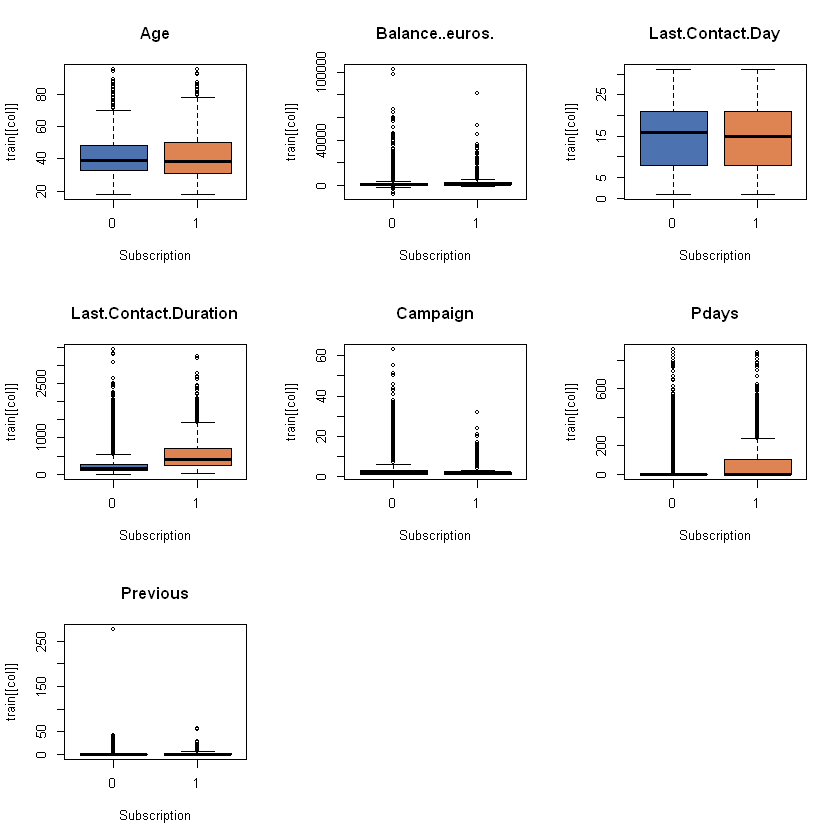

In [8]:
png("../../outputs/figures/clasificacion_boxplots_numericas.png", width = 1100, height = 900, res = 120)
par(mfrow = c(3, 3))
for (col in num_cols) {
  boxplot(train[[col]] ~ train$Subscription, main = col, xlab = "Subscription",
          col = c("#4C72B0", "#DD8452"))
}
dev.off()

par(mfrow = c(3, 3))
for (col in num_cols) {
  boxplot(train[[col]] ~ train$Subscription, main = col, xlab = "Subscription",
          col = c("#4C72B0", "#DD8452"))
}

### 3.2 Categóricas vs. Subscription (tasa de conversión por categoría)

In [9]:
for (col in cat_cols) {
  cat("\n===", col, "vs Subscription (tasa de conversión %) ===\n")
  tab <- prop.table(table(train[[col]], train$Subscription), margin = 1) * 100
  print(round(tab, 1))
}


=== Job vs Subscription (tasa de conversión %) ===
               
                   0    1
  admin.        88.1 11.9
  blue-collar   92.5  7.5
  entrepreneur  92.2  7.8
  housemaid     92.2  7.8
  management    86.1 13.9
  retired       78.3 21.7
  self-employed 88.4 11.6
  services      90.8  9.2
  student       71.4 28.6
  technician    89.1 10.9
  unemployed    83.6 16.4
  unknown       88.2 11.8

=== Marital.Status vs Subscription (tasa de conversión %) ===
          
              0    1
  divorced 88.3 11.7
  married  90.0 10.0
  single   84.7 15.3

=== Education vs Subscription (tasa de conversión %) ===
           
               0    1
  primary   91.4  8.6
  secondary 89.4 10.6
  tertiary  85.0 15.0
  unknown   87.2 12.8

=== Credit vs Subscription (tasa de conversión %) ===
     
         0    1
  no  88.2 11.8
  yes 93.7  6.3

=== Housing.Loan vs Subscription (tasa de conversión %) ===
     
         0    1
  no  83.4 16.6
  yes 92.3  7.7

=== Personal.Loan vs Subscripti

### 3.3 Caso especial: relación entre Pdays, Previous y Poutcome

In [10]:
# Pdays = -1 significa "nunca contactado antes"; debería coincidir con Poutcome = "unknown"
cat("Cruce Pdays==-1 vs Poutcome:\n")
print(table(train$Pdays == -1, train$Poutcome))

cat("\nTasa de conversión según si fue contactado antes (Pdays != -1):\n")
train$Contactado_Antes <- ifelse(train$Pdays == -1, "No", "Sí")
print(round(prop.table(table(train$Contactado_Antes, train$Subscription), margin = 1) * 100, 1))

Cruce Pdays==-1 vs Poutcome:


       
        failure other success unknown
  FALSE    3435  1251    1061       2
  TRUE        0     0       0   25899

Tasa de conversión según si fue contactado antes (Pdays != -1):
    
        0    1
  No 90.9  9.1
  Sí 76.7 23.3


### 3.4 Correlación entre variables numéricas

                        Age Balance..euros. Last.Contact.Day
Age                    1.00            0.09            -0.01
Balance..euros.        0.09            1.00             0.01
Last.Contact.Day      -0.01            0.01             1.00
Last.Contact.Duration -0.01            0.02            -0.03
Campaign               0.01           -0.01             0.16
Pdays                 -0.02            0.00            -0.10
Previous               0.00            0.01            -0.06
                      Last.Contact.Duration Campaign Pdays Previous
Age                                   -0.01     0.01 -0.02     0.00
Balance..euros.                        0.02    -0.01  0.00     0.01
Last.Contact.Day                      -0.03     0.16 -0.10    -0.06
Last.Contact.Duration                  1.00    -0.08  0.00     0.00
Campaign                              -0.08     1.00 -0.09    -0.03
Pdays                                  0.00    -0.09  1.00     0.43
Previous                            

agg_record_2b2460c2115e 
                      2

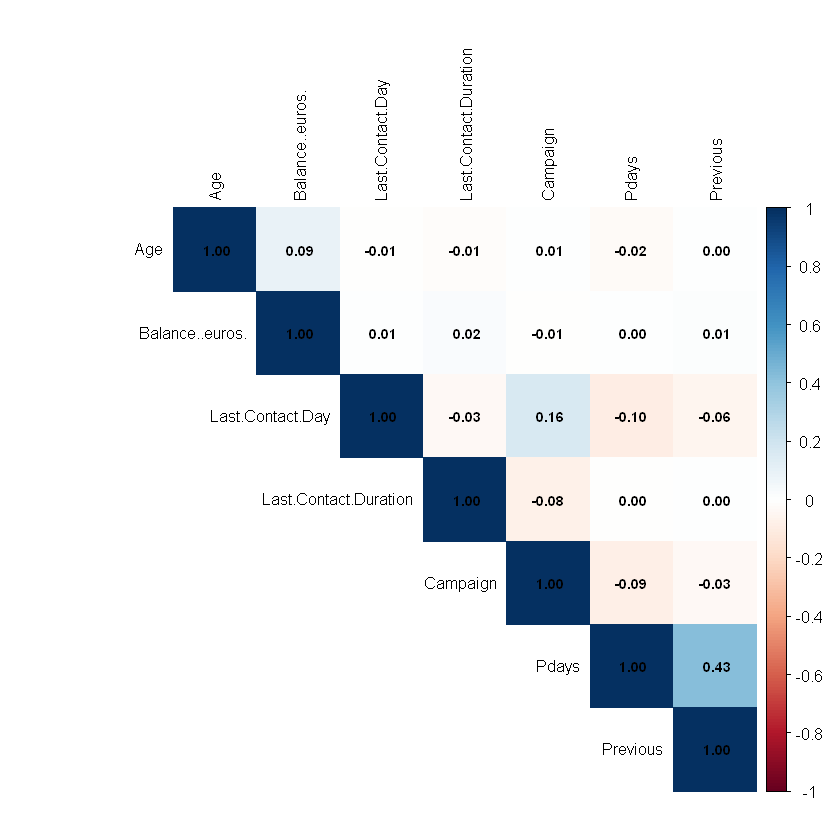

In [11]:
cor_num <- cor(train[, num_cols])
print(round(cor_num, 2))

png("../../outputs/figures/clasificacion_matriz_correlacion.png", width = 700, height = 700, res = 120)
corrplot(cor_num, method = "color", type = "upper", addCoef.col = "black",
         tl.col = "black", tl.cex = 0.8, number.cex = 0.7)
dev.off()

corrplot(cor_num, method = "color", type = "upper", addCoef.col = "black",
         tl.col = "black", tl.cex = 0.8, number.cex = 0.7)

## 4. Elección del Modelo de Clasificación

**Nota metodológica sobre Last.Contact.Duration:** según Moro, Cortez & Rita (2014),
esta variable solo se conoce después de realizada la llamada, por lo que no está
disponible en el momento de decidir a quién contactar. Se excluye del modelo
reportado en el informe (más realista para la aplicación de negocio) y se incluye
únicamente en la variante optimizada para la competencia de Kaggle (documentada
en una sección aparte), donde el criterio de evaluación (AUC) no distingue este matiz.

Se comparan dos técnicas cubiertas en el curso —regresión logística y LDA— mediante
validación cruzada, usando AUC como criterio de comparación (mismo criterio de la
competencia).

In [12]:
# Dataset para el modelo del informe: excluye Last.Contact.Duration
predictores_informe <- c("Age", "Job", "Marital.Status", "Education", "Credit",
                          "Balance..euros.", "Housing.Loan", "Personal.Loan",
                          "Contact", "Last.Contact.Day", "Last.Contact.Month",
                          "Campaign", "Pdays", "Previous", "Poutcome")

train_informe <- train[, c(predictores_informe, "Subscription")]

cat("Dimensiones dataset del informe:", nrow(train_informe), "x", ncol(train_informe), "\n")

Dimensiones dataset del informe: 31648 x 16 


In [13]:
set.seed(42)
k <- 5
folds <- createFolds(train_informe$Subscription, k = k, list = TRUE)

auc_logit <- c()
auc_lda   <- c()

for (i in 1:k) {
  idx_val <- folds[[i]]
  tr <- train_informe[-idx_val, ]
  va <- train_informe[idx_val, ]

  # Regresión logística
  m_logit <- glm(Subscription ~ ., data = tr, family = binomial)
  p_logit <- predict(m_logit, newdata = va, type = "response")
  auc_logit[i] <- as.numeric(auc(roc(va$Subscription, p_logit, quiet = TRUE)))

  # LDA
  m_lda <- lda(Subscription ~ ., data = tr)
  p_lda <- predict(m_lda, newdata = va)$posterior[, 2]
  auc_lda[i] <- as.numeric(auc(roc(va$Subscription, p_lda, quiet = TRUE)))
}

cat("AUC promedio Regresión Logística:", round(mean(auc_logit), 4), "(±", round(sd(auc_logit), 4), ")\n")
cat("AUC promedio LDA                :", round(mean(auc_lda), 4), "(±", round(sd(auc_lda), 4), ")\n")

AUC promedio Regresión Logística: 0.765 (± 0.0071 )
AUC promedio LDA                : 0.761 (± 0.005 )


### 4.1 Decisión: Regresión Logística

Aunque el AUC promedio por validación cruzada es prácticamente equivalente entre
ambas técnicas (logística: 0.765 ± 0.007; LDA: 0.761 ± 0.005 — diferencia dentro
del margen de variabilidad entre folds), se elige **regresión logística** por dos
razones adicionales:

1. **Supuestos:** LDA exige normalidad multivariada de los predictores dentro de
   cada clase. De los 15 predictores disponibles, 9 son categóricos; al codificarse
   como variables dummy, no pueden satisfacer normalidad por construcción. La
   regresión logística no impone supuestos distribucionales sobre los predictores.
2. **Interpretabilidad:** los coeficientes de la regresión logística se traducen
   directamente en odds ratios, la forma estándar de comunicar el efecto de cada
   variable en el contexto de negocio (cuánto cambian las probabilidades de que
   un cliente adquiera el producto), a diferencia de los coeficientes discriminantes
   de LDA.

## 5. Estimación de los Parámetros del Modelo

Con la técnica ya seleccionada (regresión logística), se ajusta el modelo sobre
el conjunto de predictores disponibles (excluyendo Last.Contact.Duration por
las razones ya documentadas), y se simplifica mediante una prueba de razón de
verosimilitud.


In [14]:
modelo_logit <- glm(Subscription ~ ., data = train_informe, family = binomial)
summary(modelo_logit)


Call:
glm(formula = Subscription ~ ., family = binomial, data = train_informe)

Coefficients:
                        Estimate Std. Error z value             Pr(>|z|)    
(Intercept)           -1.3506376  0.1950482   -6.92    0.000000000004371 ***
Age                    0.0027543  0.0023619    1.17              0.24357    
Jobblue-collar        -0.0643349  0.0778923   -0.83              0.40883    
Jobentrepreneur       -0.2162238  0.1349459   -1.60              0.10909    
Jobhousemaid          -0.4072610  0.1497783   -2.72              0.00655 ** 
Jobmanagement         -0.0061397  0.0789219   -0.08              0.93799    
Jobretired             0.3518855  0.1046252    3.36              0.00077 ***
Jobself-employed      -0.1196099  0.1197348   -1.00              0.31782    
Jobservices           -0.0196381  0.0882495   -0.22              0.82390    
Jobstudent             0.3632996  0.1180537    3.08              0.00209 ** 
Jobtechnician         -0.0644280  0.0747257   -0.86       

In [15]:
# Modelo reducido: quita las variables no significativas identificadas
modelo_logit_reducido <- glm(Subscription ~ Job + Marital.Status + Education +
                              Balance..euros. + Housing.Loan + Personal.Loan +
                              Contact + Last.Contact.Month + Campaign + Poutcome,
                              data = train_informe, family = binomial)

# Prueba de razón de verosimilitud: ¿el modelo completo es significativamente
# mejor que el reducido? (equivalente logístico de la prueba F parcial)
anova(modelo_logit_reducido, modelo_logit, test = "Chisq")

,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,31611,19024,NA,NA,NA
2,31606,19020,5,4.47,0.484


In [16]:
summary(modelo_logit_reducido)
cat("\nAIC completo :", AIC(modelo_logit), "\n")
cat("AIC reducido :", AIC(modelo_logit_reducido), "\n")


Call:
glm(formula = Subscription ~ Job + Marital.Status + Education + 
    Balance..euros. + Housing.Loan + Personal.Loan + Contact + 
    Last.Contact.Month + Campaign + Poutcome, family = binomial, 
    data = train_informe)

Coefficients:
                         Estimate  Std. Error z value             Pr(>|z|)    
(Intercept)           -1.13930049  0.12842110   -8.87 < 0.0000000000000002 ***
Jobblue-collar        -0.06949388  0.07783641   -0.89              0.37195    
Jobentrepreneur       -0.21516208  0.13473972   -1.60              0.11029    
Jobhousemaid          -0.39726279  0.14933895   -2.66              0.00781 ** 
Jobmanagement         -0.00289199  0.07883778   -0.04              0.97074    
Jobretired             0.40253725  0.09416118    4.27    0.000019115370379 ***
Jobself-employed      -0.12000189  0.11972806   -1.00              0.31620    
Jobservices           -0.02394755  0.08823489   -0.27              0.78608    
Jobstudent             0.33621436  0.11596864 


AIC completo : 19104 
AIC reducido : 19098 


### 5.1 Simplificación del modelo: prueba de razón de verosimilitud

Se contrastó formalmente si el bloque de variables no significativas en el modelo
completo (Age, Credit, Last.Contact.Day, Pdays, Previous) podía eliminarse sin
pérdida de ajuste, mediante una prueba de razón de verosimilitud (LRT):

H₀: los 5 coeficientes son conjuntamente cero.

Resultado: χ² = 4.47, g.l. = 5, p = 0.484. No se rechaza H₀: las variables se
eliminan sin pérdida significativa de ajuste. El AIC del modelo reducido (19,098)
es incluso menor que el del modelo completo (19,104), reforzando la simplificación.
Nótese que Pdays y Previous pierden significancia al controlar por Poutcome —su
señal bivariada (vista en el EDA) se explicaba por la fuerte redundancia entre
ambas variables (Pdays=-1 coincide con Poutcome=unknown en 25,899 de 25,901 casos).

**Modelo final: 10 predictores** — Job, Marital.Status, Education, Balance.euros.,
Housing.Loan, Personal.Loan, Contact, Last.Contact.Month, Campaign, Poutcome.

In [17]:
modelo_logit_final <- modelo_logit_reducido  # este es el modelo oficial del informe

## 6. Interpretación de los Parámetros del Modelo (Odds Ratios)

In [18]:
# Odds ratios = exp(coeficientes), con sus intervalos de confianza al 95%
odds_ratios <- exp(coef(modelo_logit_final))
ic_odds <- exp(confint(modelo_logit_final))

tabla_or <- data.frame(
  Variable = names(odds_ratios),
  OR = round(odds_ratios, 3),
  IC_2.5 = round(ic_odds[, 1], 3),
  IC_97.5 = round(ic_odds[, 2], 3)
)
print(tabla_or)

Waiting for profiling to be done...



                                   Variable    OR IC_2.5 IC_97.5
(Intercept)                     (Intercept) 0.320  0.249   0.411
Jobblue-collar               Jobblue-collar 0.933  0.801   1.087
Jobentrepreneur             Jobentrepreneur 0.806  0.616   1.045
Jobhousemaid                   Jobhousemaid 0.672  0.498   0.895
Jobmanagement                 Jobmanagement 0.997  0.855   1.164
Jobretired                       Jobretired 1.496  1.243   1.798
Jobself-employed           Jobself-employed 0.887  0.699   1.118
Jobservices                     Jobservices 0.976  0.821   1.160
Jobstudent                       Jobstudent 1.400  1.114   1.755
Jobtechnician                 Jobtechnician 0.937  0.810   1.085
Jobunemployed                 Jobunemployed 1.223  0.975   1.527
Jobunknown                       Jobunknown 0.938  0.564   1.494
Marital.Statusmarried Marital.Statusmarried 0.828  0.734   0.937
Marital.Statussingle   Marital.Statussingle 1.142  1.003   1.302
Educationsecondary       

### 6.1 Interpretación de los odds ratios

**Poutcome (resultado de campaña anterior) — el predictor más fuerte:**
Un cliente cuya campaña anterior fue exitosa (`success`) tiene **9.1 veces** las
chances de adquirir el nuevo producto frente a un cliente cuya campaña anterior
fracasó (`failure`), manteniendo todo lo demás constante (IC 95%: 7.68–10.81).
Este es, por un margen amplio, el hallazgo de mayor relevancia de negocio: la
lealtad/receptividad previa del cliente es el mejor predictor disponible.

**Préstamos — efecto protector negativo:**
Tener préstamo hipotecario (`Housing.Loan=yes`) reduce las chances en un 41.8%
(OR = 0.582), y tener préstamo personal (`Personal.Loan=yes`) las reduce en un
32.8% (OR = 0.672). Clientes con compromisos financieros existentes muestran
menor propensión a adquirir un nuevo producto financiero.

**Canal de contacto:**
Cuando el canal de contacto es desconocido (`Contact=unknown`), las chances caen
en un 74% (OR = 0.260) frente a contacto por celular (categoría base). Esto
probablemente refleja calidad de datos (contactos mal registrados) más que un
efecto causal del canal en sí.

**Estacionalidad (Last.Contact.Month):**
Los meses de marzo (OR = 2.77), septiembre (OR = 1.81) y octubre (OR = 1.71)
muestran las mayores chances relativas de conversión frente a abril (categoría
base), mientras que mayo, julio, agosto, enero y noviembre muestran chances
reducidas. Este patrón podría estar asociado a campañas de menor volumen pero
mejor dirigidas en esos meses (recordar que en el EDA estos meses tenían pocas
observaciones), o a factores estacionales del producto financiero.

**Educación:**
A mayor nivel educativo, mayores las chances: educación terciaria (universitaria)
incrementa las chances en 36.3% (OR = 1.363) frente a educación primaria.

**Número de contactos en la campaña actual (Campaign):**
Cada contacto adicional en la campaña actual reduce las chances en un 8.5%
(OR = 0.915) — sugiere que la insistencia excesiva tiene un efecto contraproducente,
posiblemente por fatiga o desgaste del cliente.

**Balance:**
El efecto de Balance..euros. es estadísticamente significativo pero de magnitud
económica insignificante (OR ≈ 1.000 por cada euro adicional) — su significancia
se debe al gran tamaño muestral, no a un efecto sustantivo.

## 7. Desempeño del Clasificador

AUC (train): 0.768 


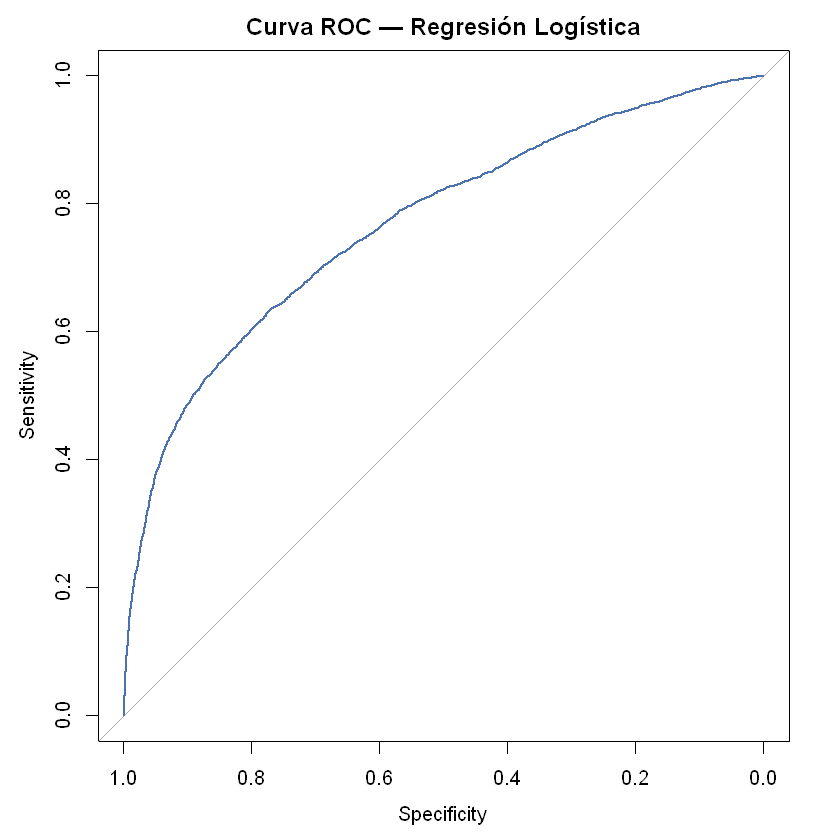

In [19]:
# Predicciones (probabilidades) sobre el propio conjunto de entrenamiento
prob_pred <- predict(modelo_logit_final, type = "response")

# Curva ROC y AUC
roc_obj <- roc(train_informe$Subscription, prob_pred, quiet = TRUE)
cat("AUC (train):", round(auc(roc_obj), 4), "\n")

plot(roc_obj, col = "#4C72B0", lwd = 2, main = "Curva ROC — Regresión Logística")

In [20]:
# Matriz de confusión con umbral 0.5 (punto de partida estándar)
clase_pred <- ifelse(prob_pred > 0.5, 1, 0)
matriz_conf <- confusionMatrix(as.factor(clase_pred), train_informe$Subscription, positive = "1")
print(matriz_conf)

Confusion Matrix and Statistics

          Reference
Prediction     0     1
         0 27607  3038
         1   344   659
                                              
               Accuracy : 0.893               
                 95% CI : (0.89, 0.897)       
    No Information Rate : 0.883               
    P-Value [Acc > NIR] : 0.0000000126        
                                              
                  Kappa : 0.243               
                                              
 Mcnemar's Test P-Value : < 0.0000000000000002
                                              
            Sensitivity : 0.1783              
            Specificity : 0.9877              
         Pos Pred Value : 0.6570              
         Neg Pred Value : 0.9009              
             Prevalence : 0.1168              
         Detection Rate : 0.0208              
   Detection Prevalence : 0.0317              
      Balanced Accuracy : 0.5830              
                                

### 7.1 Selección de umbral óptimo (índice de Youden)

In [21]:
# El umbral 0.5 no es óptimo con clases desbalanceadas.
# Youden's J = sensibilidad + especificidad - 1; buscamos el umbral que lo maximiza
coords_optimo <- coords(roc_obj, x = "best", best.method = "youden",
                         ret = c("threshold", "sensitivity", "specificity"))
print(coords_optimo)

umbral_optimo <- coords_optimo$threshold
cat("\nUmbral óptimo (Youden):", round(umbral_optimo, 4), "\n")

  threshold sensitivity specificity
1     0.123       0.631       0.775

Umbral óptimo (Youden): 0.123 


In [22]:
# Matriz de confusión con el umbral óptimo
clase_pred_opt <- ifelse(prob_pred > umbral_optimo, 1, 0)
matriz_conf_opt <- confusionMatrix(as.factor(clase_pred_opt), train_informe$Subscription, positive = "1")
print(matriz_conf_opt)

Confusion Matrix and Statistics

          Reference
Prediction     0     1
         0 21666  1366
         1  6285  2331
                                             
               Accuracy : 0.758              
                 95% CI : (0.753, 0.763)     
    No Information Rate : 0.883              
    P-Value [Acc > NIR] : 1                  
                                             
                  Kappa : 0.257              
                                             
 Mcnemar's Test P-Value : <0.0000000000000002
                                             
            Sensitivity : 0.6305             
            Specificity : 0.7751             
         Pos Pred Value : 0.2705             
         Neg Pred Value : 0.9407             
             Prevalence : 0.1168             
         Detection Rate : 0.0737             
   Detection Prevalence : 0.2722             
      Balanced Accuracy : 0.7028             
                                             
    

### 7.2 Desempeño del clasificador: comparación de umbrales

El modelo logra un **AUC = 0.768** en el conjunto de entrenamiento (consistente
con el 0.765 ± 0.007 estimado por validación cruzada de 5 folds, lo que descarta
sobreajuste relevante). Dado que la elección del umbral de clasificación tiene
implicaciones directas de negocio, se comparan dos escenarios:

| Métrica | Umbral = 0.5 (estándar) | Umbral = 0.123 (óptimo, Youden) |
|---|---|---|
| Sensibilidad (recall positivos) | 17.8% | 63.1% |
| Especificidad | 98.8% | 77.5% |
| Accuracy global | 89.3% | 75.8% |
| Valor predictivo positivo | 65.7% | 27.1% |
| Balanced Accuracy | 58.3% | 70.3% |

**Interpretación de negocio:** con el umbral estándar de 0.5, el modelo es
extremadamente conservador: de cada 100 clientes que realmente adquirirían el
producto, detecta solo 18. El accuracy global (89.3%) es engañosamente alto —
reflejo del desbalance de clases (88.3% no adquiere), no de buen desempeño real
del clasificador para el objetivo de negocio (identificar candidatos).

Con el umbral óptimo (0.123, que maximiza el índice de Youden), el modelo detecta
al 63.1% de los verdaderos compradores, a costa de contactar también a más
clientes que no comprarán (especificidad baja a 77.5%). Esta es la elección más
alineada con el objetivo del gerente de UniBank: identificar candidatos
prometedores para una campaña de marketing, donde el costo de un falso positivo
(contactar a alguien que no compra) es mucho menor que el costo de un falso
negativo (no contactar a alguien que sí hubiera comprado). Se recomienda operar
con el umbral óptimo o uno similar, ajustable según el presupuesto de contactos
que el banco esté dispuesto a asumir.